# Case Study (Loan Tap)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data= pd.read_csv("loan_tap.csv")
data.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


------------

______________

### a. Observations on shape of data and data types of all attributes


In [3]:
target_variable=data['loan_status']

In [4]:
data.shape

(86895, 27)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86895 entries, 0 to 86894
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   loan_amnt             86895 non-null  float64
 1   term                  86895 non-null  object 
 2   int_rate              86895 non-null  float64
 3   installment           86895 non-null  float64
 4   grade                 86895 non-null  object 
 5   sub_grade             86895 non-null  object 
 6   emp_title             81889 non-null  object 
 7   emp_length            82891 non-null  object 
 8   home_ownership        86895 non-null  object 
 9   annual_inc            86895 non-null  float64
 10  verification_status   86895 non-null  object 
 11  issue_d               86895 non-null  object 
 12  loan_status           86895 non-null  object 
 13  purpose               86894 non-null  object 
 14  title                 86512 non-null  object 
 15  dti                

### b. Check for missing value (if any)


In [6]:
data.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
emp_title,5006
emp_length,4004
home_ownership,0
annual_inc,0


### c. Display the statistical summary


In [7]:
data.describe()

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,86895.000000,86895.000000,86895.000000,8.689500e+04,86894.000000,86894.000000,86894.000000,8.689400e+04,86831.000000,86894.000000,78627.000000,86799.000000
mean,14109.744232,13.644640,431.587666,7.428735e+04,17.321671,11.310459,0.178263,1.584490e+04,53.831055,25.439121,1.812253,0.121672
std,8376.506321,4.460588,251.284777,5.475222e+04,8.140833,5.133150,0.509095,1.974742e+04,24.390066,11.876350,2.139010,0.356672
min,500.000000,5.320000,16.310000,2.500000e+03,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000
25%,8000.000000,10.490000,250.290000,4.500000e+04,11.280000,8.000000,0.000000,6.061000e+03,36.000000,17.000000,0.000000,0.000000
50%,12000.000000,13.330000,375.290000,6.400000e+04,16.840000,10.000000,0.000000,1.120000e+04,54.900000,24.000000,1.000000,0.000000
75%,20000.000000,16.490000,568.615000,9.000000e+04,22.910000,14.000000,0.000000,1.961775e+04,72.800000,32.000000,3.000000,0.000000
max,40000.000000,30.990000,1533.810000,6.100000e+06,189.900000,58.000000,19.000000,1.190046e+06,152.500000,135.000000,34.000000,7.000000


### d. Univariate Analysis and Bivariate Analysis of all the attributes



Target Variable Distribution:
loan_status
Fully Paid     69936
Charged Off    16958
Charged            1
Name: count, dtype: int64


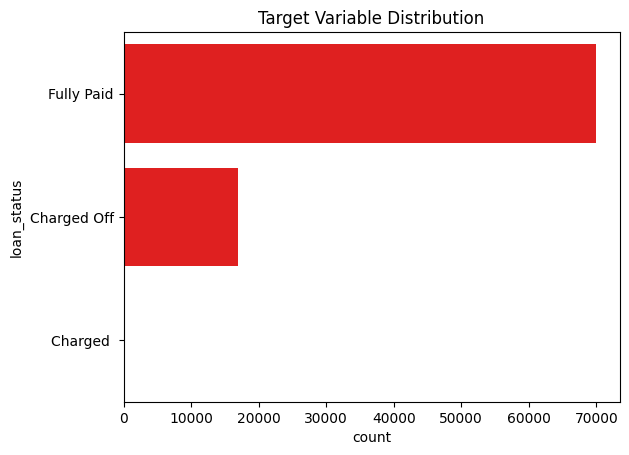

In [8]:
print(f"\nTarget Variable Distribution:\n{target_variable.value_counts()}")
sns.countplot(target_variable, color='red')
plt.title("Target Variable Distribution")
plt.show()

#### Univeriate

In [9]:
numerical_data= data.select_dtypes(include=['int64','float64']).columns
categorical_data=data.select_dtypes(include='object').columns

In [10]:
data[numerical_data]

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
0,10000.0,11.44,329.48,117000.0,26.24,16.0,0.0,36369.0,41.8,25.0,0.0,0.0
1,8000.0,11.99,265.68,65000.0,22.05,17.0,0.0,20131.0,53.3,27.0,3.0,0.0
2,15600.0,10.49,506.97,43057.0,12.79,13.0,0.0,11987.0,92.2,26.0,0.0,0.0
3,7200.0,6.49,220.65,54000.0,2.60,6.0,0.0,5472.0,21.5,13.0,0.0,0.0
4,24375.0,17.27,609.33,55000.0,33.95,13.0,0.0,24584.0,69.8,43.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
86890,10000.0,19.52,262.28,55000.0,22.45,22.0,0.0,11986.0,29.6,31.0,0.0,0.0
86891,10000.0,13.53,339.50,87500.0,17.30,10.0,1.0,9389.0,46.3,18.0,3.0,1.0
86892,15000.0,16.99,534.72,92000.0,24.08,17.0,0.0,102260.0,89.6,34.0,3.0,0.0
86893,10000.0,12.69,335.45,60000.0,19.98,21.0,0.0,9465.0,31.2,46.0,3.0,0.0


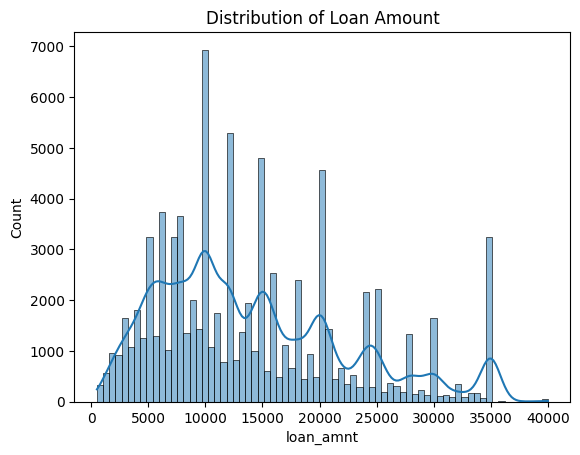

In [11]:
sns.histplot(data['loan_amnt'], kde=True)
plt.title('Distribution of Loan Amount')
plt.show()

The Loan amount is mostly segregated in the range of 5000-20000 <br>
No need to check for outliers in this feature


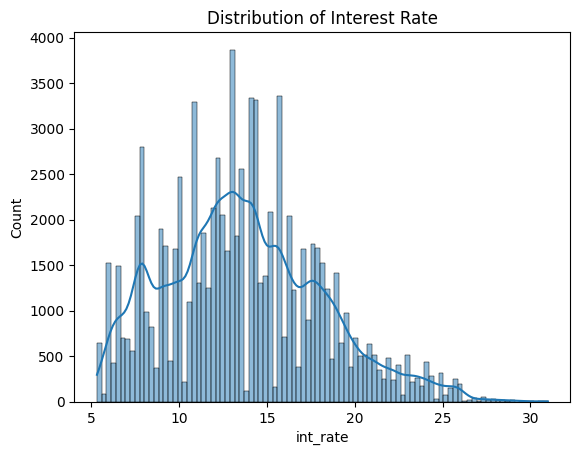

In [12]:
sns.histplot(data['int_rate'], kde=True)
plt.title('Distribution of Interest Rate')
plt.show()

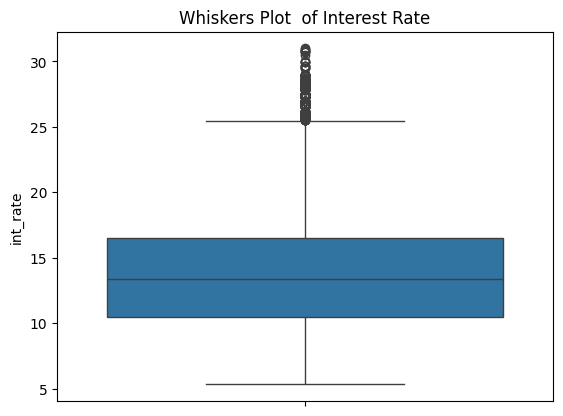

In [13]:
sns.boxplot(data=data['int_rate'])
plt.title('Whiskers Plot  of Interest Rate')
plt.show()

Their are numerous outliers in the interest rate


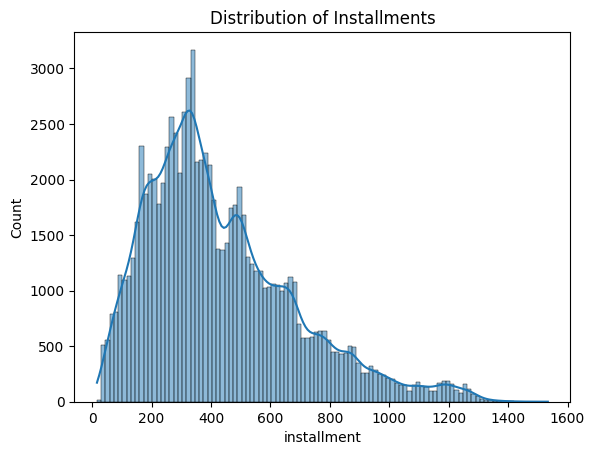

In [14]:
sns.histplot(data['installment'], kde=True)
plt.title('Distribution of Installments')
plt.show()

##### Correlation Analysis (Numerical Features)


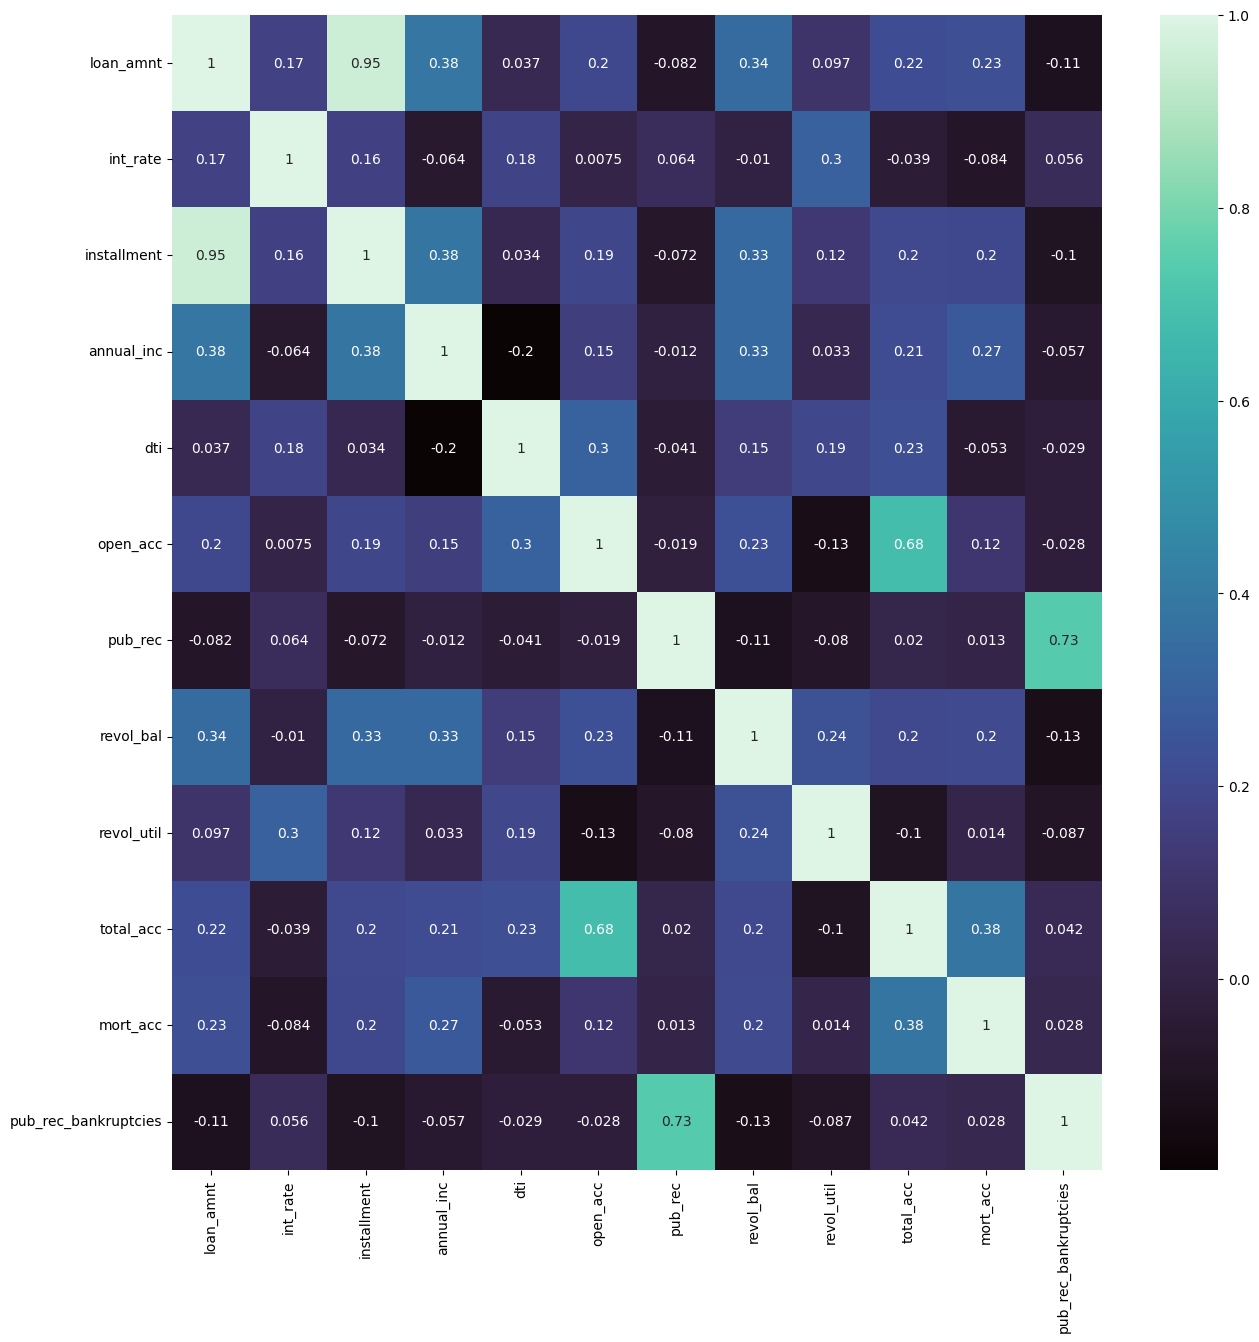

In [15]:
plt.figure(figsize=(15,15))
sns.heatmap(data=data[numerical_data].corr(), annot=True, cmap=sns.color_palette("mako", as_cmap=True))
plt.show()

----

#### Bivariate

In [16]:
data[categorical_data].head(6)

,term,grade,sub_grade,emp_title,emp_length,home_ownership,verification_status,issue_d,loan_status,purpose,title,earliest_cr_line,initial_list_status,application_type,address
0,36 months,B,B4,Marketing,10+ years,RENT,Not Verified,Jan-2015,Fully Paid,vacation,Vacation,Jun-1990,w,INDIVIDUAL,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,36 months,B,B5,Credit analyst,4 years,MORTGAGE,Not Verified,Jan-2015,Fully Paid,debt_consolidation,Debt consolidation,Jul-2004,f,INDIVIDUAL,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,36 months,B,B3,Statistician,< 1 year,RENT,Source Verified,Jan-2015,Fully Paid,credit_card,Credit card refinancing,Aug-2007,f,INDIVIDUAL,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,36 months,A,A2,Client Advocate,6 years,RENT,Not Verified,Nov-2014,Fully Paid,credit_card,Credit card refinancing,Sep-2006,f,INDIVIDUAL,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,60 months,C,C5,Destiny Management Inc.,9 years,MORTGAGE,Verified,Apr-2013,Charged Off,credit_card,Credit Card Refinance,Mar-1999,f,INDIVIDUAL,"679 Luna Roads\r\nGreggshire, VA 11650"
5,36 months,C,C3,HR Specialist,10+ years,MORTGAGE,Verified,Sep-2015,Fully Paid,debt_consolidation,Debt consolidation,Jan-2005,f,INDIVIDUAL,1726 Cooper Passage Suite 129\r\nNorth Deniseb...


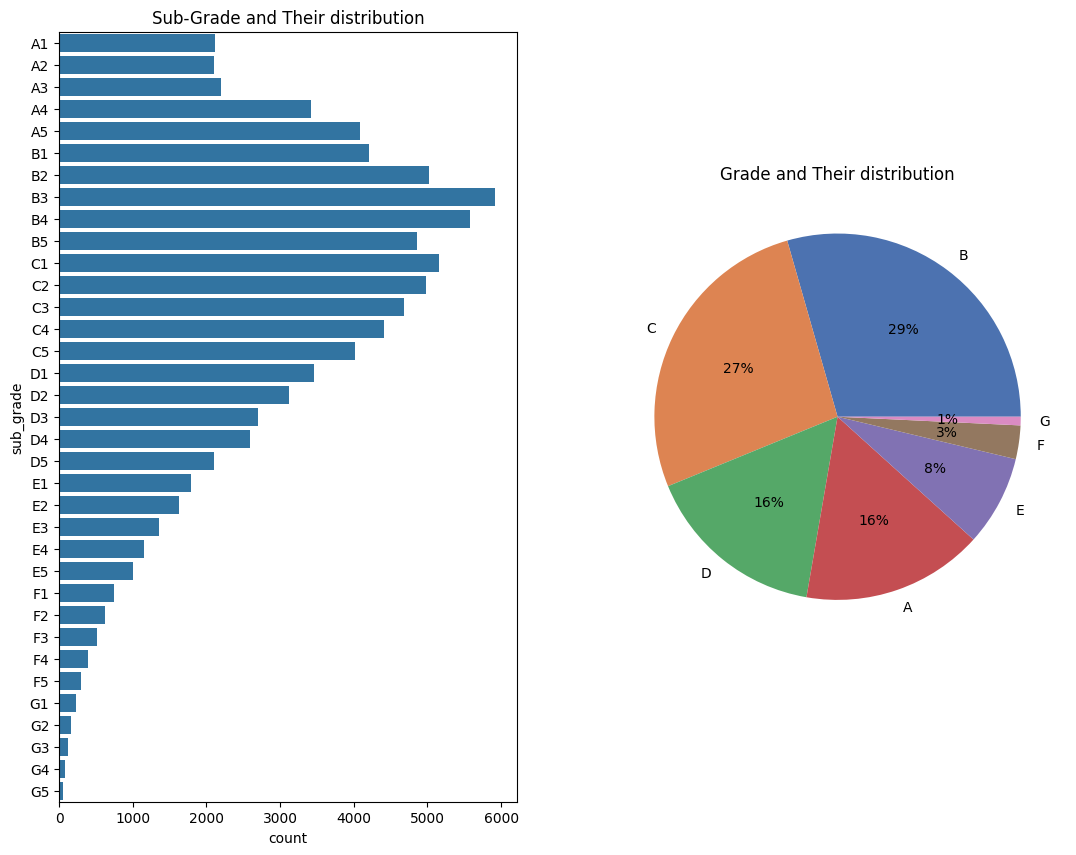

In [17]:
plt.figure(figsize=(13,10))

plt.subplot(1,2,2)
plt.pie(data['grade'].value_counts().values, labels=data['grade'].value_counts().index, colors=sns.color_palette('deep'), autopct='%.0f%%')
plt.title('Grade and Their distribution')

plt.subplot(1,2,1)
sns.countplot(data['sub_grade'].sort_values())
plt.title('Sub-Grade and Their distribution')

plt.show()

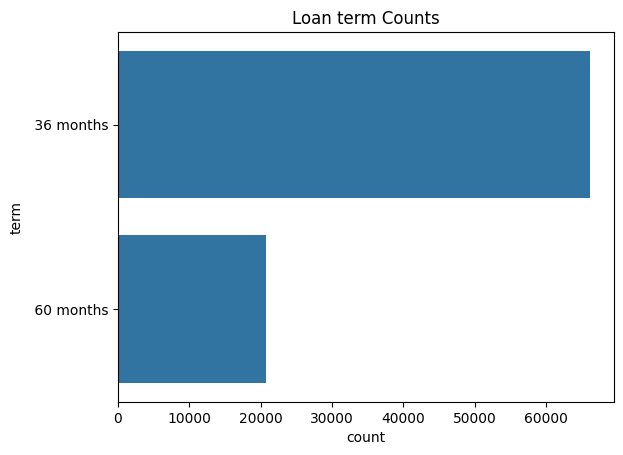

In [18]:
sns.countplot(data['term'].sort_values())
plt.title('Loan term Counts')

plt.show()

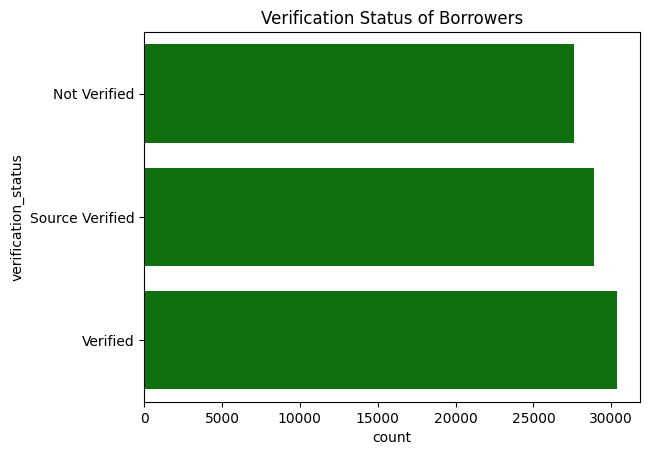

In [19]:
sns.countplot(data['verification_status'].sort_values() , color='green')
plt.title('Verification Status of Borrowers')

plt.show()

In [20]:
print(data[categorical_data].describe())

              term  grade sub_grade emp_title emp_length home_ownership  \
count        86895  86895     86895     81889      82891          86895   
unique           2      7        35     47042         11              6   
top      36 months      B        B3   Teacher  10+ years       MORTGAGE   
freq         66186  25577      5919       969      27724          43575   

       verification_status   issue_d loan_status             purpose  \
count                86895     86895       86895               86894   
unique                   3       115           3                  14   
top               Verified  Oct-2014  Fully Paid  debt_consolidation   
freq                 30341      3241       69936               51343   

                     title earliest_cr_line initial_list_status  \
count                86512            86894               86894   
unique               13224              623                   2   
top     Debt consolidation         Oct-2001                   

In [21]:
data[numerical_data].describe()

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,86895.000000,86895.000000,86895.000000,8.689500e+04,86894.000000,86894.000000,86894.000000,8.689400e+04,86831.000000,86894.000000,78627.000000,86799.000000
mean,14109.744232,13.644640,431.587666,7.428735e+04,17.321671,11.310459,0.178263,1.584490e+04,53.831055,25.439121,1.812253,0.121672
std,8376.506321,4.460588,251.284777,5.475222e+04,8.140833,5.133150,0.509095,1.974742e+04,24.390066,11.876350,2.139010,0.356672
min,500.000000,5.320000,16.310000,2.500000e+03,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000
25%,8000.000000,10.490000,250.290000,4.500000e+04,11.280000,8.000000,0.000000,6.061000e+03,36.000000,17.000000,0.000000,0.000000
50%,12000.000000,13.330000,375.290000,6.400000e+04,16.840000,10.000000,0.000000,1.120000e+04,54.900000,24.000000,1.000000,0.000000
75%,20000.000000,16.490000,568.615000,9.000000e+04,22.910000,14.000000,0.000000,1.961775e+04,72.800000,32.000000,3.000000,0.000000
max,40000.000000,30.990000,1533.810000,6.100000e+06,189.900000,58.000000,19.000000,1.190046e+06,152.500000,135.000000,34.000000,7.000000


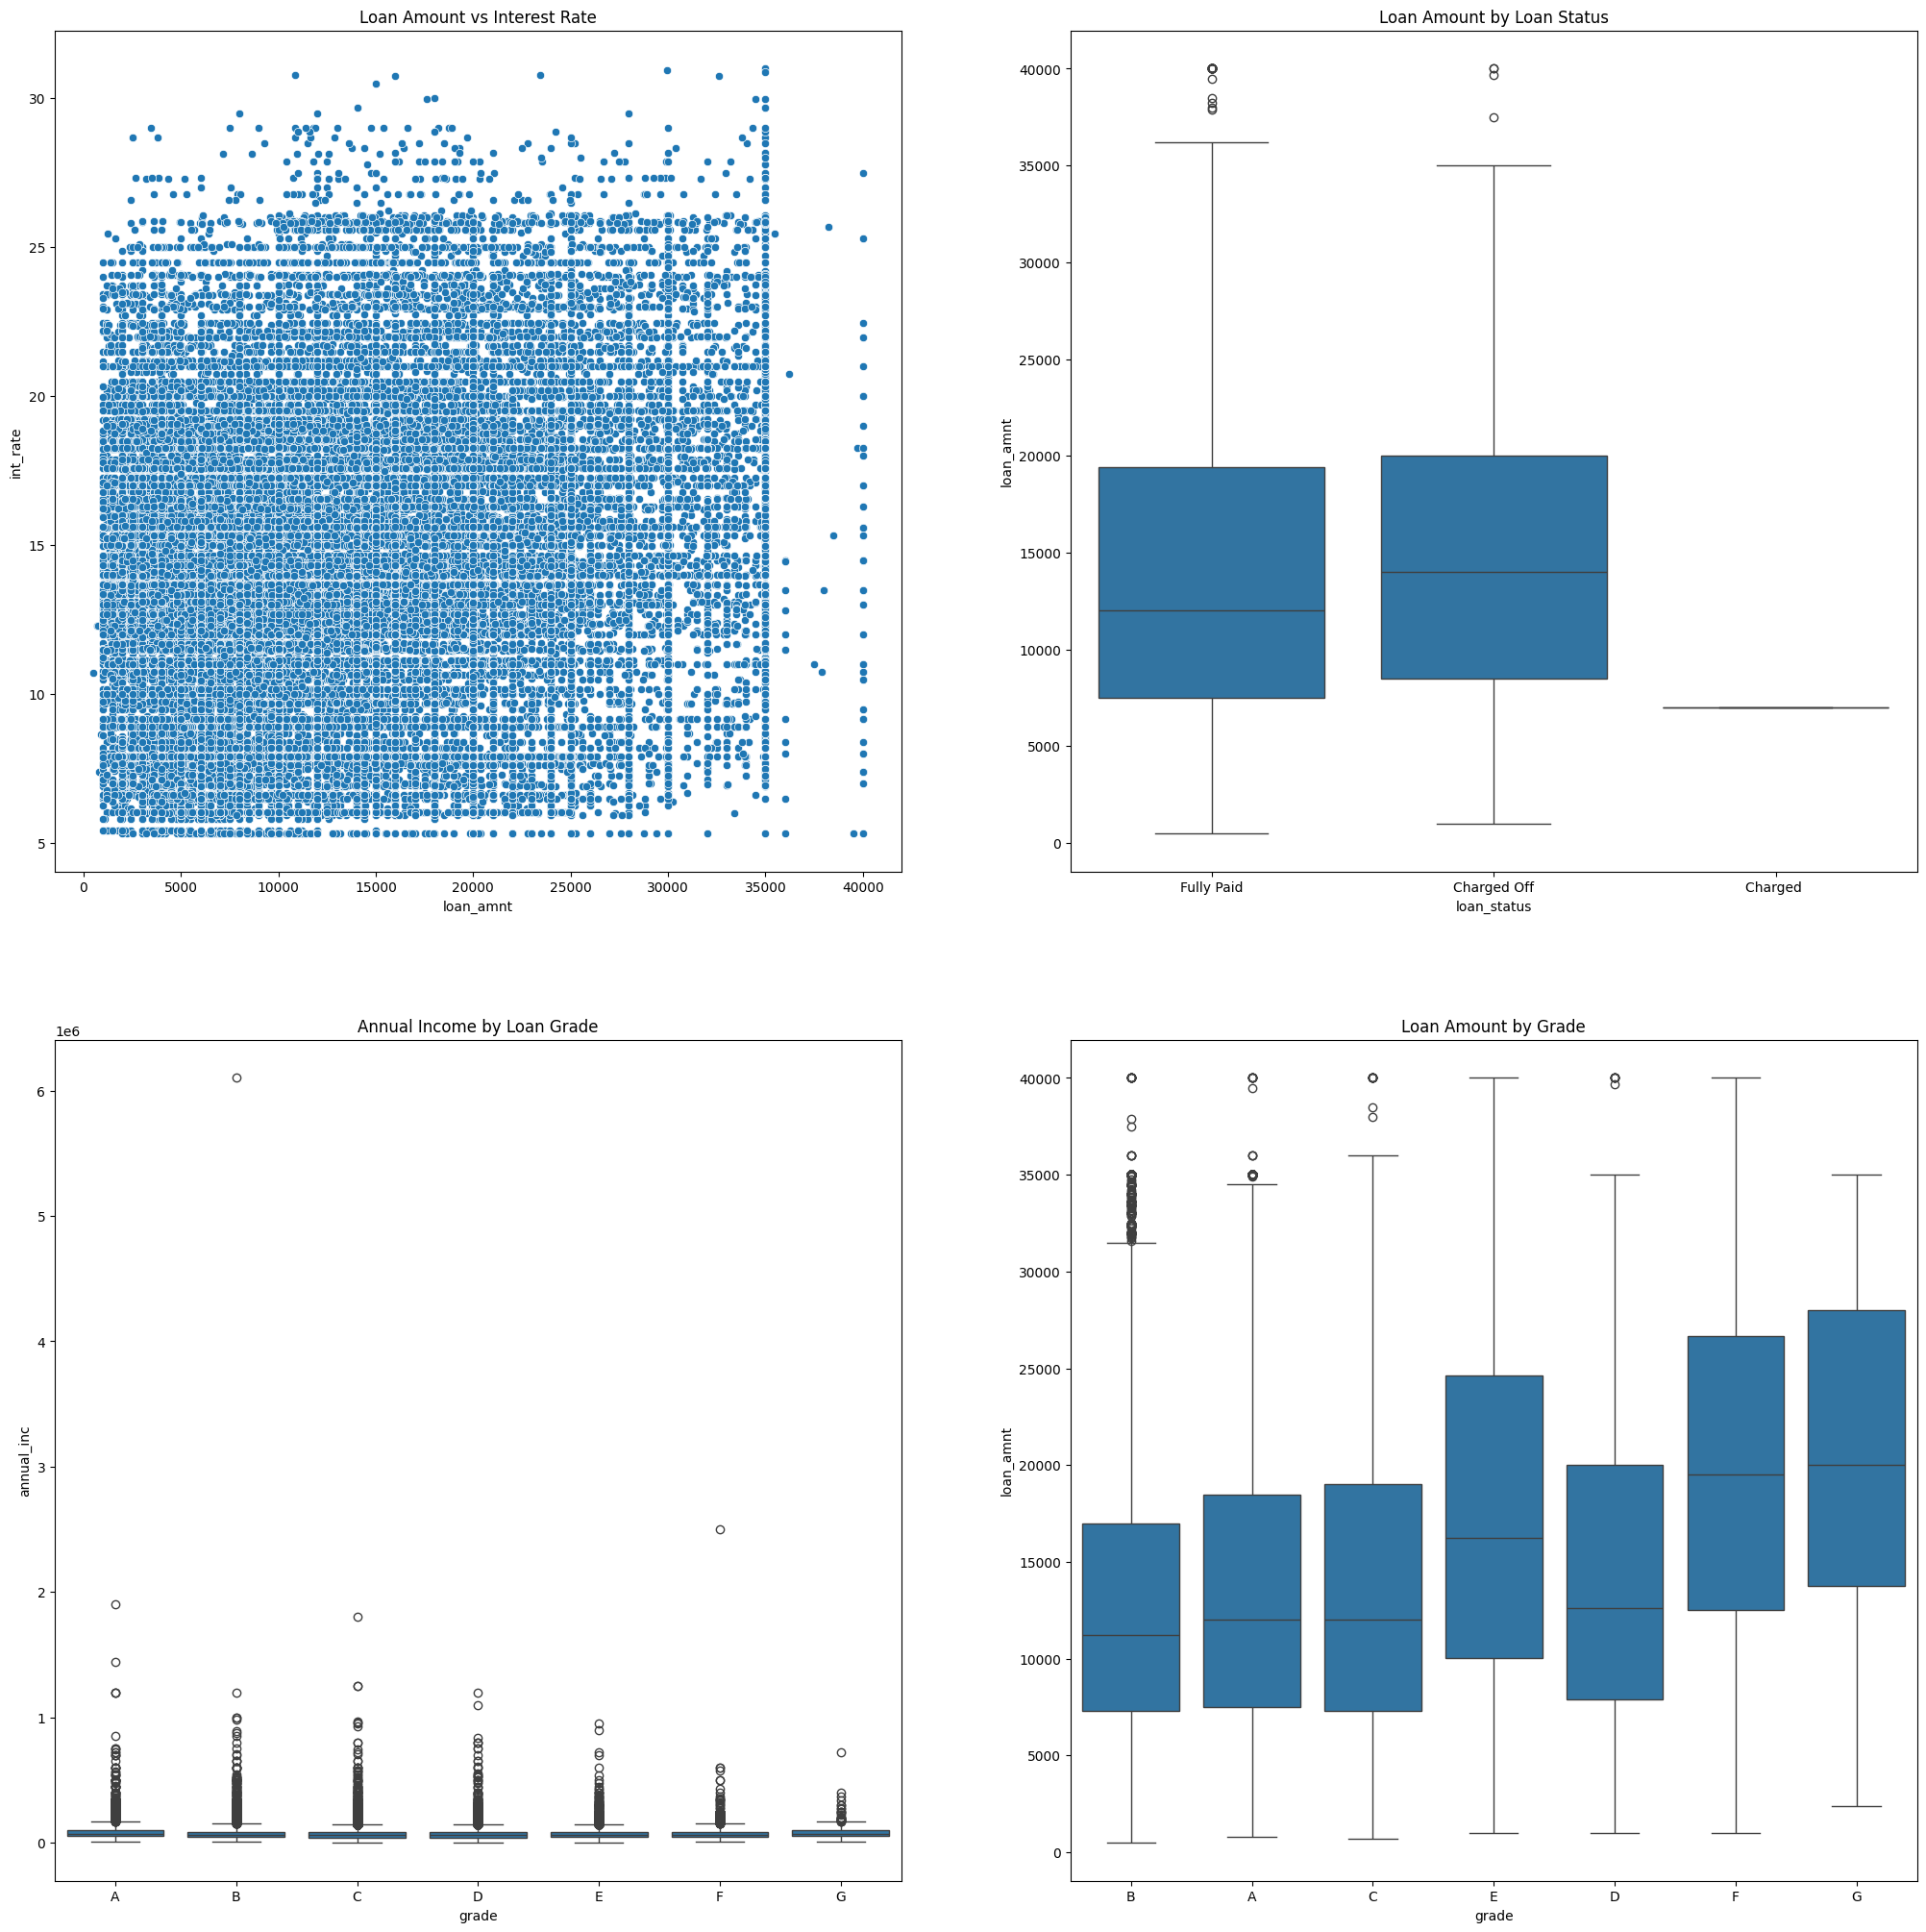

In [22]:
plt.figure(figsize=(25,25))

plt.subplot(2,2,1)
# Scatter plot between loan amount and interest rate
sns.scatterplot(x='loan_amnt', y='int_rate', data=data)
plt.title('Loan Amount vs Interest Rate')

plt.subplot(2,2,2)
sns.boxplot(x=target_variable, y=data['loan_amnt'])
plt.title('Loan Amount by Loan Status')

plt.subplot(2,2,3)
sns.boxplot(x='grade', y='annual_inc', data=data, order=sorted(data['grade'].unique()))
plt.title('Annual Income by Loan Grade')

plt.subplot(2,2,4)
sns.boxplot(x='grade', y='loan_amnt', data=data)
plt.title('Loan Amount by Grade')



plt.show()


home_ownership  ANY  MORTGAGE  NONE  OTHER   OWN   RENT
loan_status                                            
Charged           0         1     0      0     0      0
Charged Off       0      7415     1      7  1663   7872
Fully Paid        1     36159     5     15  6599  27157


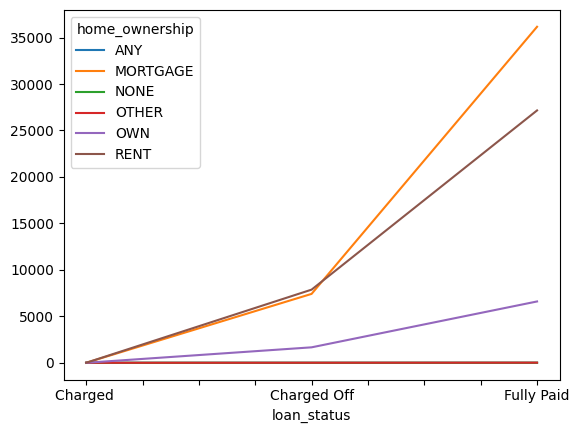

In [23]:
crosstab = pd.crosstab(target_variable, data['home_ownership'])
print(crosstab)

crosstab.plot()
plt.show()

### Comments:


    a. On range of attributes


- Loan amount ranges from 500-40000
- Range of Interest Rate : 5.3% - 31%
- Average annual Income : 74203
- Average Debt to Income Ratio is : 7.4%
- Average number of open credit lines in the borrower's credit file : 11.3
- Total Deregatory Records : 396030
- Average Revolving Balance : 15844.5


In [24]:
data['revol_bal'].mean()

np.float64(15844.901707827928)

    b. Outliers of various attributes


In [25]:
# funcion to calculate lower bound & upper bound of a feature
def detect_outliers_iqr(column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound,upper_bound

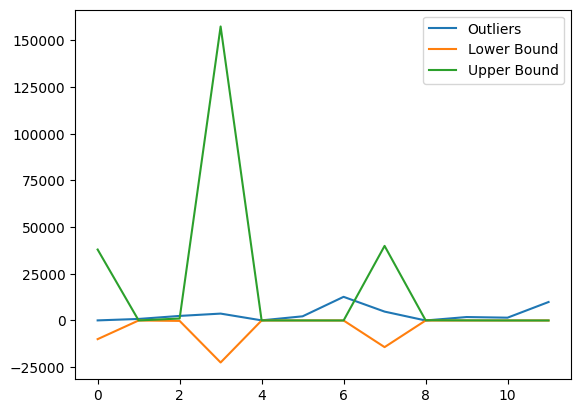

In [26]:
outliers_summary_list = []

# Loop through numerical columns and calculate outliers
for col in numerical_data:
    outliers, lower, upper = detect_outliers_iqr(col)

    # Append the results as a dictionary to the list
    outliers_summary_list.append({
        'Column': col,
        'Outliers': len(outliers),
        'Lower Bound': lower,
        'Upper Bound': upper
    })

# Convert the list of dictionaries into a DataFrame
outliers_summary = pd.DataFrame(outliers_summary_list)

# Display the summary DataFrame
outliers_summary.plot()
plt.show()

-------------------

----------

In [27]:
# Identify Missing Values
missing_values_data = data.isnull().sum()
print( missing_values_data[missing_values_data > 0])

emp_title               5006
emp_length              4004
purpose                    1
title                    383
dti                        1
earliest_cr_line           1
open_acc                   1
pub_rec                    1
revol_bal                  1
revol_util                64
total_acc                  1
initial_list_status        1
application_type           1
mort_acc                8268
pub_rec_bankruptcies      96
address                    1
dtype: int64


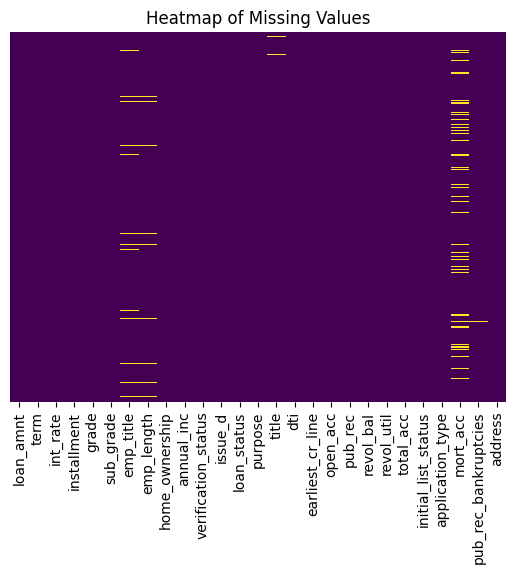

In [28]:
sns.heatmap(data.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Heatmap of Missing Values')
plt.show()

In [29]:
# Calculating the percentage of missing values
missing_percentage = round((missing_values_data / len(data)) * 100,2)

In [30]:
missing_data_summary = pd.DataFrame({
    'Missing Values': missing_values_data[missing_values_data > 0],
    'Percentage (%)': missing_percentage[missing_values_data > 0]
}).sort_values(by='Percentage (%)', ascending=False)

missing_data_summary

,Missing Values,Percentage (%)
mort_acc,8268,9.51
emp_title,5006,5.76
emp_length,4004,4.61
title,383,0.44
pub_rec_bankruptcies,96,0.11
revol_util,64,0.07
dti,1,0.00
purpose,1,0.00
pub_rec,1,0.00
open_acc,1,0.00


mort_acc :

- Replace with the median or mode, as it's a small percentage and likely skewed


Skewness: 1.5800218228961738
Kurtosis: 4.445639703466403


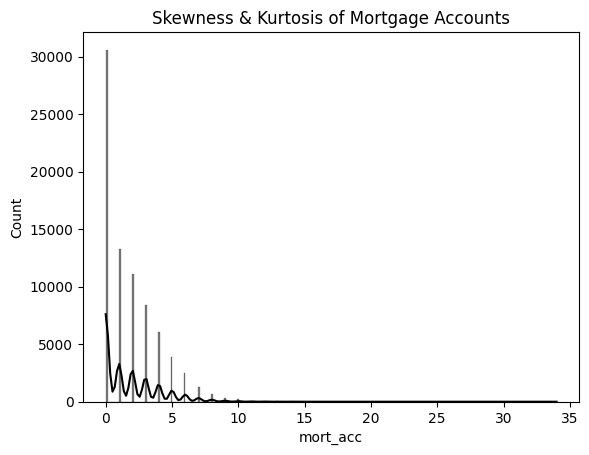

In [31]:
# Calculate skewness and kurtosis
print("Skewness:", data['mort_acc'].skew())
print("Kurtosis:", data['mort_acc'].kurt())

sns.histplot(data=data['mort_acc'],kde=True, color='black')
plt.title('Skewness & Kurtosis of Mortgage Accounts')
plt.show()

In [32]:
data['mort_acc']=data['mort_acc'].fillna(data['mort_acc'].median())

Treating pub_rec_bankruptcies by replacing missing values with the mode


### c. Outlier Treatment


     detect_outliers_iqr function is already defined in the abouve cells to reduce code redundancy

Loan amount 'loan_amnt'


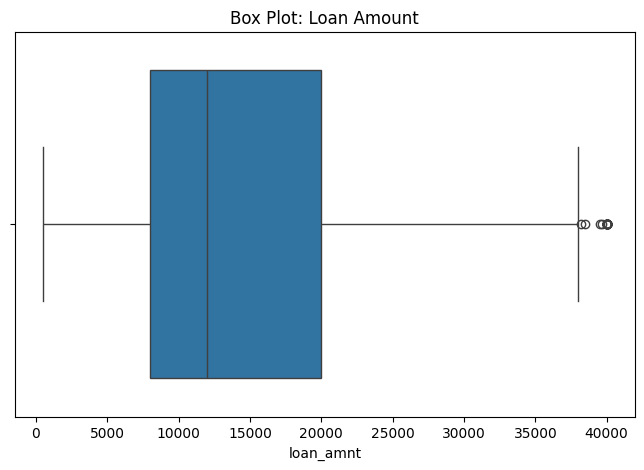

In [33]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=data['loan_amnt'])
plt.title('Box Plot: Loan Amount')
plt.show()

-----------------

Interest Rate 'int_rate'


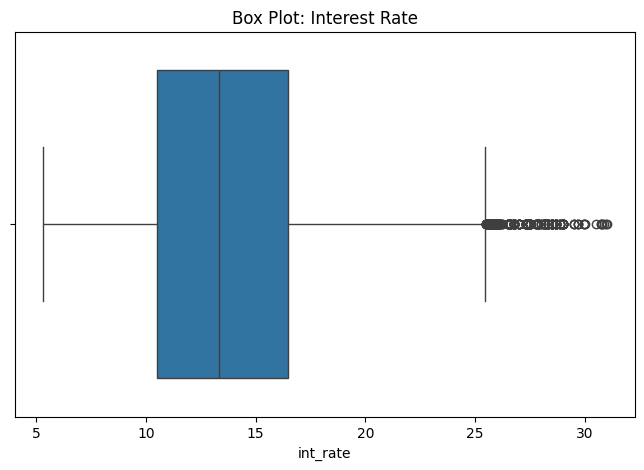

(821, np.float64(1.4900000000000038), np.float64(25.489999999999995))

In [34]:
# Extraction upper,lower bound & outlier
int_rate_outliers, int_rate_lower, int_rate_upper = detect_outliers_iqr('int_rate')

plt.figure(figsize=(8, 5))
sns.boxplot(x=data['int_rate'])
plt.title('Box Plot: Interest Rate')
plt.show()

len(int_rate_outliers), int_rate_lower, int_rate_upper


By Domain Knowledge we know <br>The inerest rate is critical to the analysis,Hence no treatment should be performed


--------------

installment


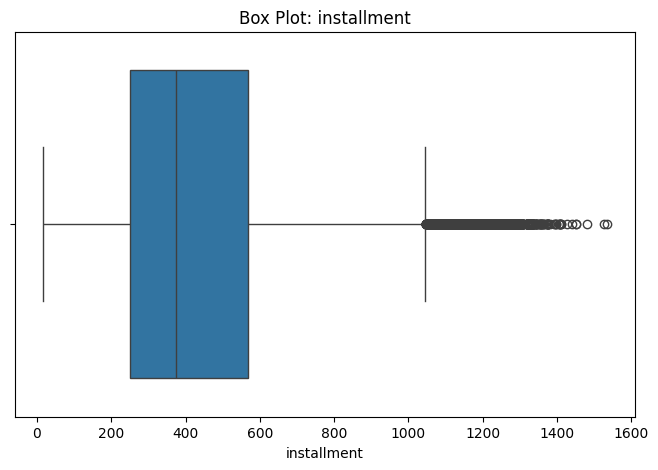

(2442, np.float64(-227.19750000000008), np.float64(1046.1025))

In [35]:
# Extraction upper,lower bound & outlier
installment_outliers, installment_lower, installment_upper = detect_outliers_iqr('installment')

plt.figure(figsize=(8, 5))
sns.boxplot(x=data['installment'])
plt.title('Box Plot: installment')
plt.show()

len(installment_outliers), installment_lower, installment_upper


-------------

Annual income 'annual_inc'


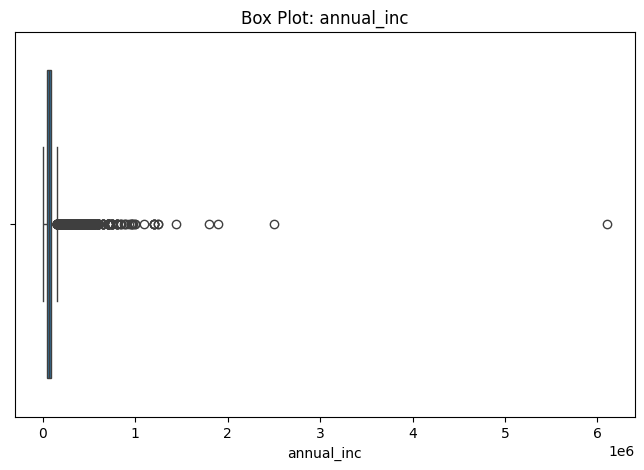

(3683, np.float64(-22500.0), np.float64(157500.0))

In [36]:
# Extraction upper,lower bound & outlier
annual_inc_outliers, annual_inc_lower, annual_inc_upper = detect_outliers_iqr('annual_inc')

plt.figure(figsize=(8, 5))
sns.boxplot(x=data['annual_inc'])
plt.title('Box Plot: annual_inc')
plt.show()

len(annual_inc_outliers), annual_inc_lower, annual_inc_upper



-------------

Debt to Income ratio 'dti' <br>

This is also can not be treated as it has much information


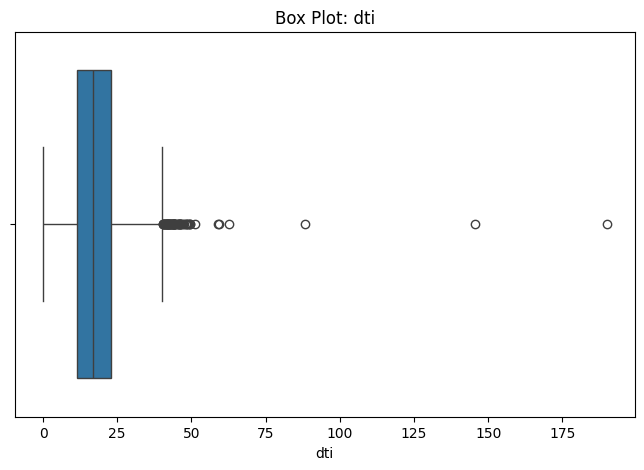

(64, np.float64(-6.165000000000001), np.float64(40.355000000000004))

In [37]:
# Extraction upper,lower bound & outlier
dti_outliers, dti_lower, dti_upper = detect_outliers_iqr('dti')

plt.figure(figsize=(8, 5))
sns.boxplot(x=data['dti'])
plt.title('Box Plot: dti')
plt.show()

len(dti_outliers), dti_lower, dti_upper

----------

--------------